In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import researchpy as rp
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
from scipy import stats

In [2]:
df_0 = pd.read_csv('C:\\Users\\miche\\Documents\\MSDS692\\IBM_Wat_EMPL_Data.csv')

In [3]:
#Explore the dataset 
print(df_0.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
print(df_0.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
#Look at an overview of numerical data
print(df_0.describe().round(2))

           Age  DailyRate  DistanceFromHome  Education  EmployeeCount  \
count  1470.00    1470.00           1470.00    1470.00         1470.0   
mean     36.92     802.49              9.19       2.91            1.0   
std       9.14     403.51              8.11       1.02            0.0   
min      18.00     102.00              1.00       1.00            1.0   
25%      30.00     465.00              2.00       2.00            1.0   
50%      36.00     802.00              7.00       3.00            1.0   
75%      43.00    1157.00             14.00       4.00            1.0   
max      60.00    1499.00             29.00       5.00            1.0   

       EmployeeNumber  EnvironmentSatisfaction  HourlyRate  JobInvolvement  \
count         1470.00                  1470.00     1470.00         1470.00   
mean          1024.87                     2.72       65.89            2.73   
std            602.02                     1.09       20.33            0.71   
min              1.00         

In [6]:
#Look at an overview of non-numerical data
for col in df_0.select_dtypes(include=['object', 'category']).columns:
    print(f"\nColumn: {col}")
    print(df_0[col].value_counts())


Column: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Column: BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Column: Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Column: EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Column: Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

Column: JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int

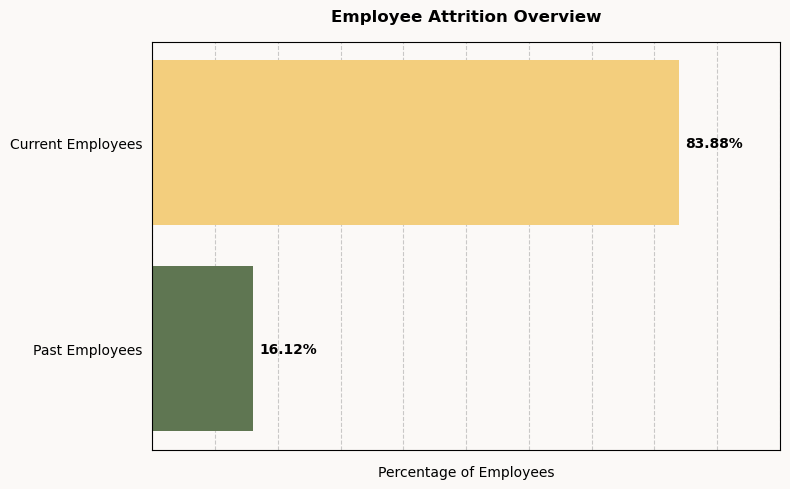

In [7]:
#Horizontal Bar Chart of Employee Attrition
#Find percentages of attrition
attrition_pct = (
    df_0["Attrition"]
    .value_counts(normalize=True)
    .rename({"No": "Current Employees", "Yes": "Past Employees"})
    * 100
)

#Show Current Employees and then Past Employees
attrition_pct = attrition_pct.reindex(["Past Employees", "Current Employees"])

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#fbf9f7")
ax.set_facecolor("#fbf9f7")
colors = ["#5f7652", "#f3ce7d"]

bars = ax.barh(
    attrition_pct.index,
    attrition_pct.values,
    color=colors
)

#Set a limit on x-axis as 100%
ax.set_xlim(0, 100)
ax.xaxis.grid(True, linestyle="--", linewidth=0.8, color="gray", alpha=0.4)
ax.set_axisbelow(True)

ax.tick_params(left=False, bottom=False)
ax.set_xticks(range(0, 101, 10))  
ax.set_xticklabels([])

ax.set_xlabel("Percentage of Employees")
ax.set_title("Employee Attrition Overview", pad=15, weight="bold")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        ha="left",
        color="black",
        weight="bold"
    )

plt.tight_layout()
plt.show()

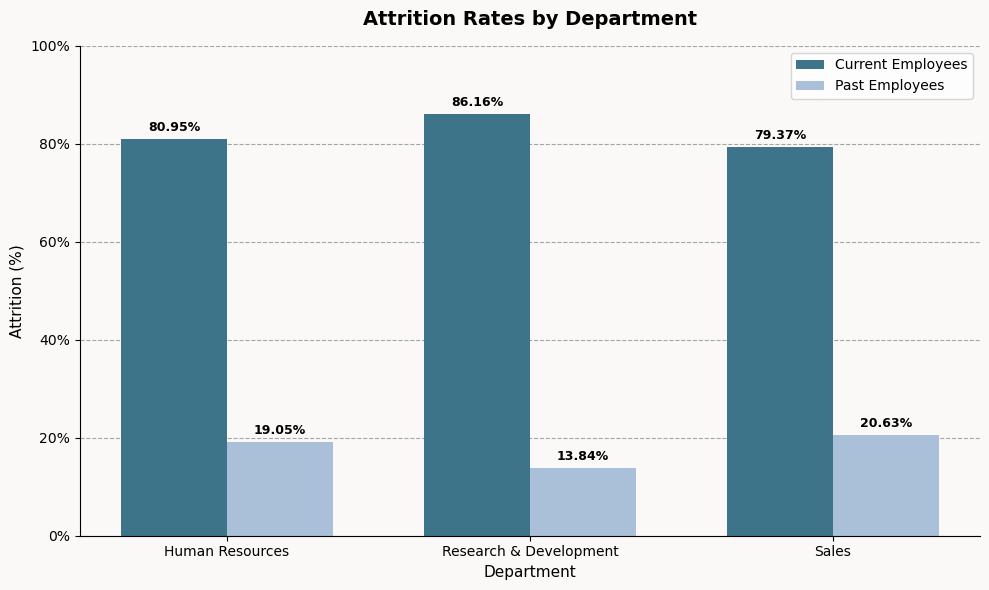

In [8]:
#Column Chart of Employee Attrition by Department
df_temp = df_0.copy()
df_temp['Attrition'] = df_temp['Attrition'].map({'Yes': 'Past Employees', 'No': 'Current Employees'})

#Attrition counts per Department
attrition_counts = df_temp.groupby(['Department', 'Attrition']).size().unstack(fill_value=0)

for col in ['Current Employees', 'Past Employees']:
    if col not in attrition_counts.columns:
        attrition_counts[col] = 0

#Calculate % and rounded to 2 decimals
attrition_pct = attrition_counts.div(attrition_counts.sum(axis=1), axis=0).mul(100).round(2)
attrition_pct = attrition_pct[['Current Employees', 'Past Employees']]

fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Current Employees': '#3d7489', 'Past Employees': '#a9c0d8'}

departments = attrition_pct.index.tolist()
x = np.arange(len(departments))
bar_width = 0.35

#Specifically for side-by-side bars
for i, col in enumerate(['Current Employees', 'Past Employees']):
    offset = (i - 0.5) * bar_width
    bars = ax.bar(
        x + offset,
        attrition_pct[col],
        width=bar_width,
        label=col,
        color=colors[col]
    )
    for bar, val in zip(bars, attrition_pct[col]):
        if val > 2:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f'{val}%',
                ha='center', va='bottom',
                fontsize=9, color='black', fontweight='bold'
            )

fig.patch.set_facecolor('#fbf9f7')
ax.set_facecolor('#fbf9f7')

ax.set_title('Attrition Rates by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=11)
ax.set_ylabel('Attrition (%)', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(departments)

#Set Y-axis limits 0 to 100%
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))

ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.7)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

ax.legend(title=None, fontsize=10, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

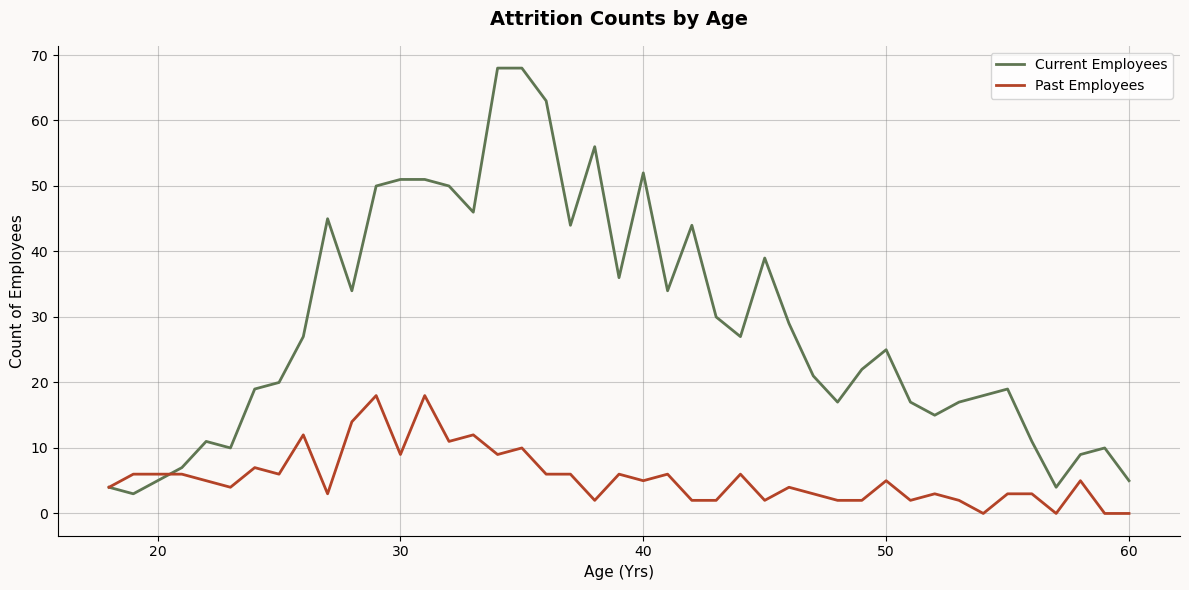

In [9]:
#Line Chart of Employee Attrition by Age
#Attrition counts by Age
age_counts = df_temp.groupby(['Age', 'Attrition']).size().unstack(fill_value=0)

for col in ['Current Employees', 'Past Employees']:
    if col not in age_counts.columns:
        age_counts[col] = 0

age_counts = age_counts[['Current Employees', 'Past Employees']].reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor('#fbf9f7')
ax.set_facecolor('#fbf9f7')

ax.plot(age_counts['Age'], age_counts['Current Employees'],
        color='#5f7652', linewidth=2, label='Current Employees')
ax.plot(age_counts['Age'], age_counts['Past Employees'],
        color='#b34327', linewidth=2, label='Past Employees')

ax.set_title('Attrition Counts by Age', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age (Yrs)', fontsize=11)
ax.set_ylabel('Count of Employees', fontsize=11)

ax.grid(True, which='both', axis='both', linestyle='-', color='gray', alpha=0.4)
ax.set_axisbelow(True)

ax.legend(title=None, fontsize=10, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

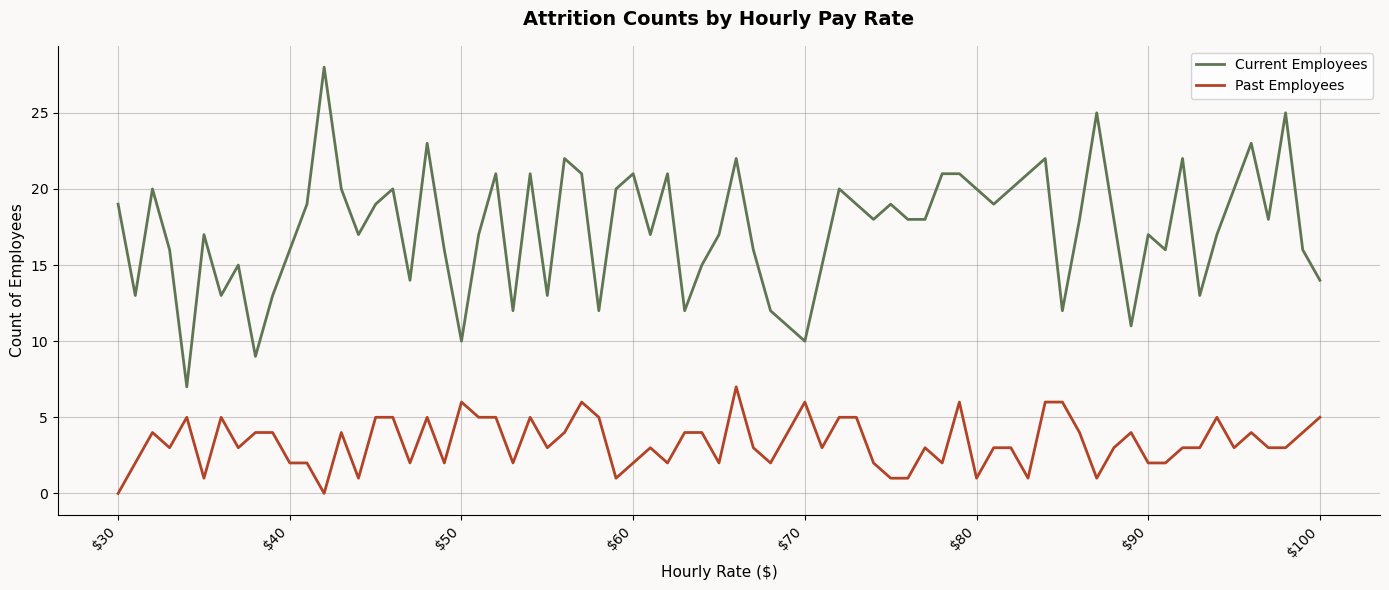

In [10]:
#Line Chart of Employee Attrition by Hourly Pay
#Attrition counts by Hourly Pay
hourly_counts = df_temp.groupby(['HourlyRate', 'Attrition']).size().unstack(fill_value=0)

for col in ['Current Employees', 'Past Employees']:
    if col not in hourly_counts.columns:
        hourly_counts[col] = 0

hourly_counts = hourly_counts[['Current Employees', 'Past Employees']].reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

fig.patch.set_facecolor('#fbf9f7')
ax.set_facecolor('#fbf9f7')

ax.plot(hourly_counts['HourlyRate'], hourly_counts['Current Employees'],
        color='#5f7652', linewidth=2, label='Current Employees')
ax.plot(hourly_counts['HourlyRate'], hourly_counts['Past Employees'],
        color='#b34327', linewidth=2, label='Past Employees')

ax.set_title('Attrition Counts by Hourly Pay Rate', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hourly Rate ($)', fontsize=11)
ax.set_ylabel('Count of Employees', fontsize=11)

#Add in $ and comma separators
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))
plt.xticks(rotation=45, ha='right')

ax.grid(True, which='both', axis='both', linestyle='-', color='gray', alpha=0.4)
ax.set_axisbelow(True)

ax.legend(title=None, fontsize=10, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

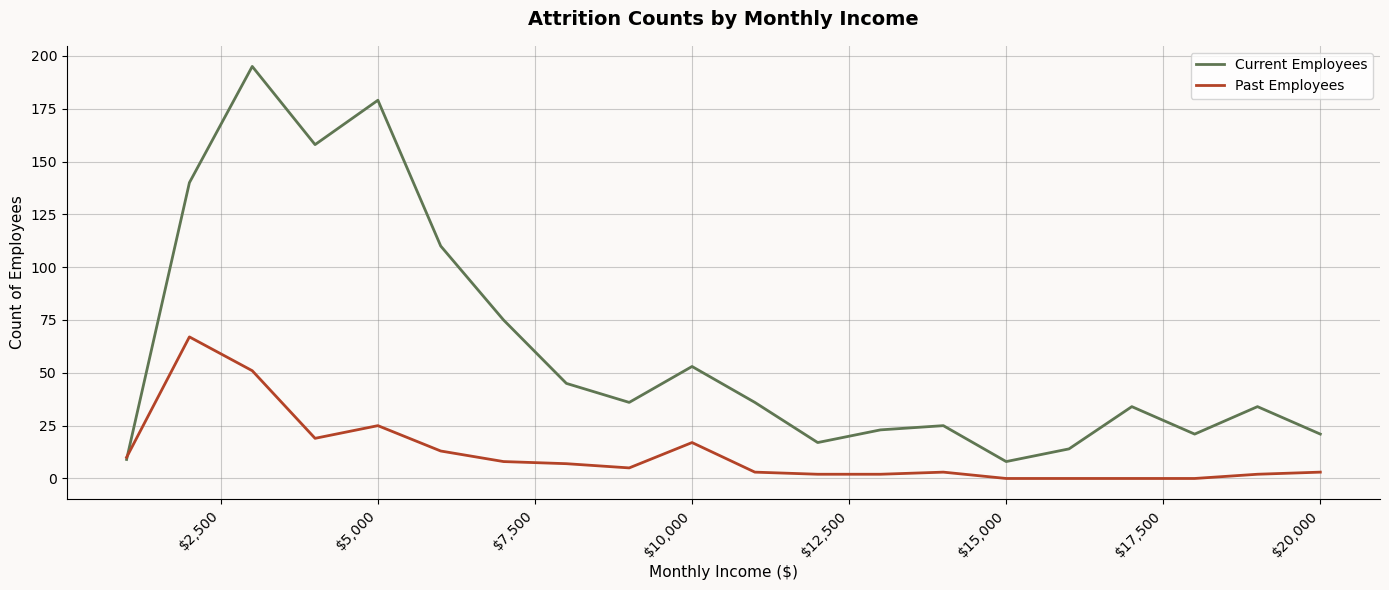

In [11]:
#Line Chart of Employee Attrition by Monthly Income
#Attrition counts by Hourly Pay
rate_att = df_temp[['MonthlyIncome', 'Attrition']].copy()
rate_att['MonthlyIncome'] = round(rate_att['MonthlyIncome'], -3)
rate_att = rate_att.groupby(['MonthlyIncome', 'Attrition']).apply(
    lambda x: x['MonthlyIncome'].count()
).reset_index(name='Counts')

# Pivot for a better plotting
income_counts = rate_att.pivot(index='MonthlyIncome', columns='Attrition', values='Counts').fillna(0)

for col in ['Current Employees', 'Past Employees']:
    if col not in income_counts.columns:
        income_counts[col] = 0

income_counts = income_counts[['Current Employees', 'Past Employees']].reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

fig.patch.set_facecolor('#fbf9f7')
ax.set_facecolor('#fbf9f7')

ax.plot(income_counts['MonthlyIncome'], income_counts['Current Employees'],
        color='#5f7652', linewidth=2, label='Current Employees')
ax.plot(income_counts['MonthlyIncome'], income_counts['Past Employees'],
        color='#b34327', linewidth=2, label='Past Employees')

ax.set_title('Attrition Counts by Monthly Income', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Income ($)', fontsize=11)
ax.set_ylabel('Count of Employees', fontsize=11)

#Add in $ and comma separators
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))
plt.xticks(rotation=45, ha='right')

ax.grid(True, which='both', axis='both', linestyle='-', color='gray', alpha=0.4)
ax.set_axisbelow(True)

ax.legend(title=None, fontsize=10, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

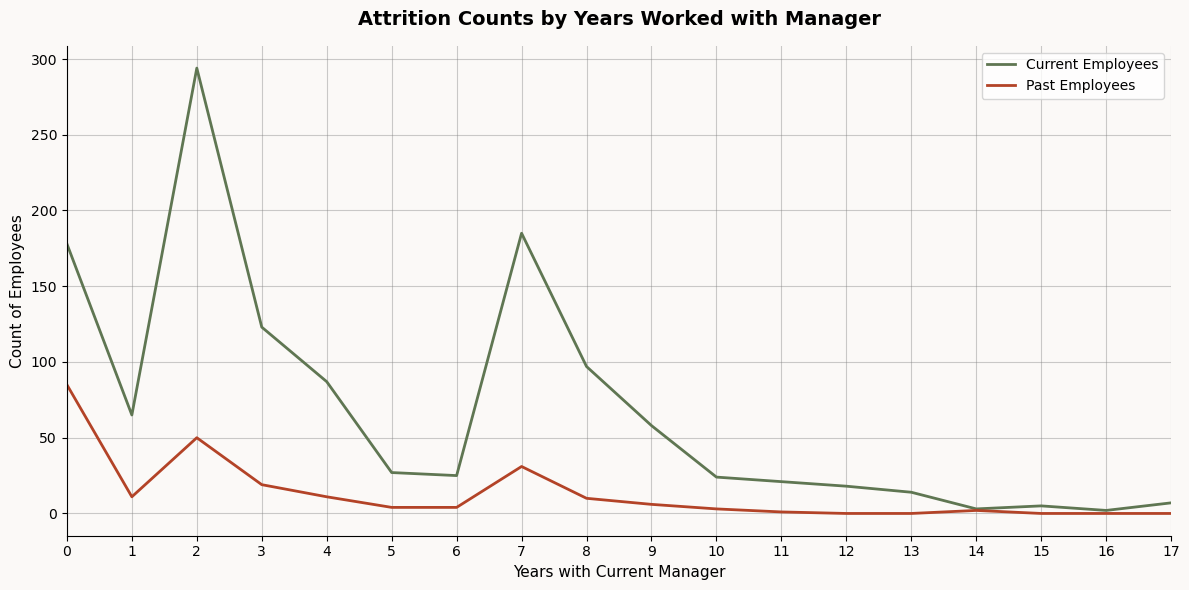

In [12]:
#Line Chart of Employee Attrition by Years with Current Manager
#Attrition counts by Years with Current Manager
years_counts = df_temp.groupby(['YearsWithCurrManager', 'Attrition']).size().unstack(fill_value=0)

for col in ['Current Employees', 'Past Employees']:
    if col not in years_counts.columns:
        years_counts[col] = 0

years_counts = years_counts[['Current Employees', 'Past Employees']].reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor('#fbf9f7')
ax.set_facecolor('#fbf9f7')

ax.plot(years_counts['YearsWithCurrManager'], years_counts['Current Employees'],
        color='#5f7652', linewidth=2, label='Current Employees')
ax.plot(years_counts['YearsWithCurrManager'], years_counts['Past Employees'],
        color='#b34327', linewidth=2, label='Past Employees')

ax.set_title('Attrition Counts by Years Worked with Manager', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Years with Current Manager', fontsize=11)
ax.set_ylabel('Count of Employees', fontsize=11)

#Set x-axis minimum value to 0 
ax.set_xlim(0, years_counts['YearsWithCurrManager'].max())

#Show whole numbers only
ax.set_xticks(years_counts['YearsWithCurrManager'])

ax.grid(True, which='both', axis='both', linestyle='-', color='gray', alpha=0.4)
ax.set_axisbelow(True)

ax.legend(title=None, fontsize=10, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

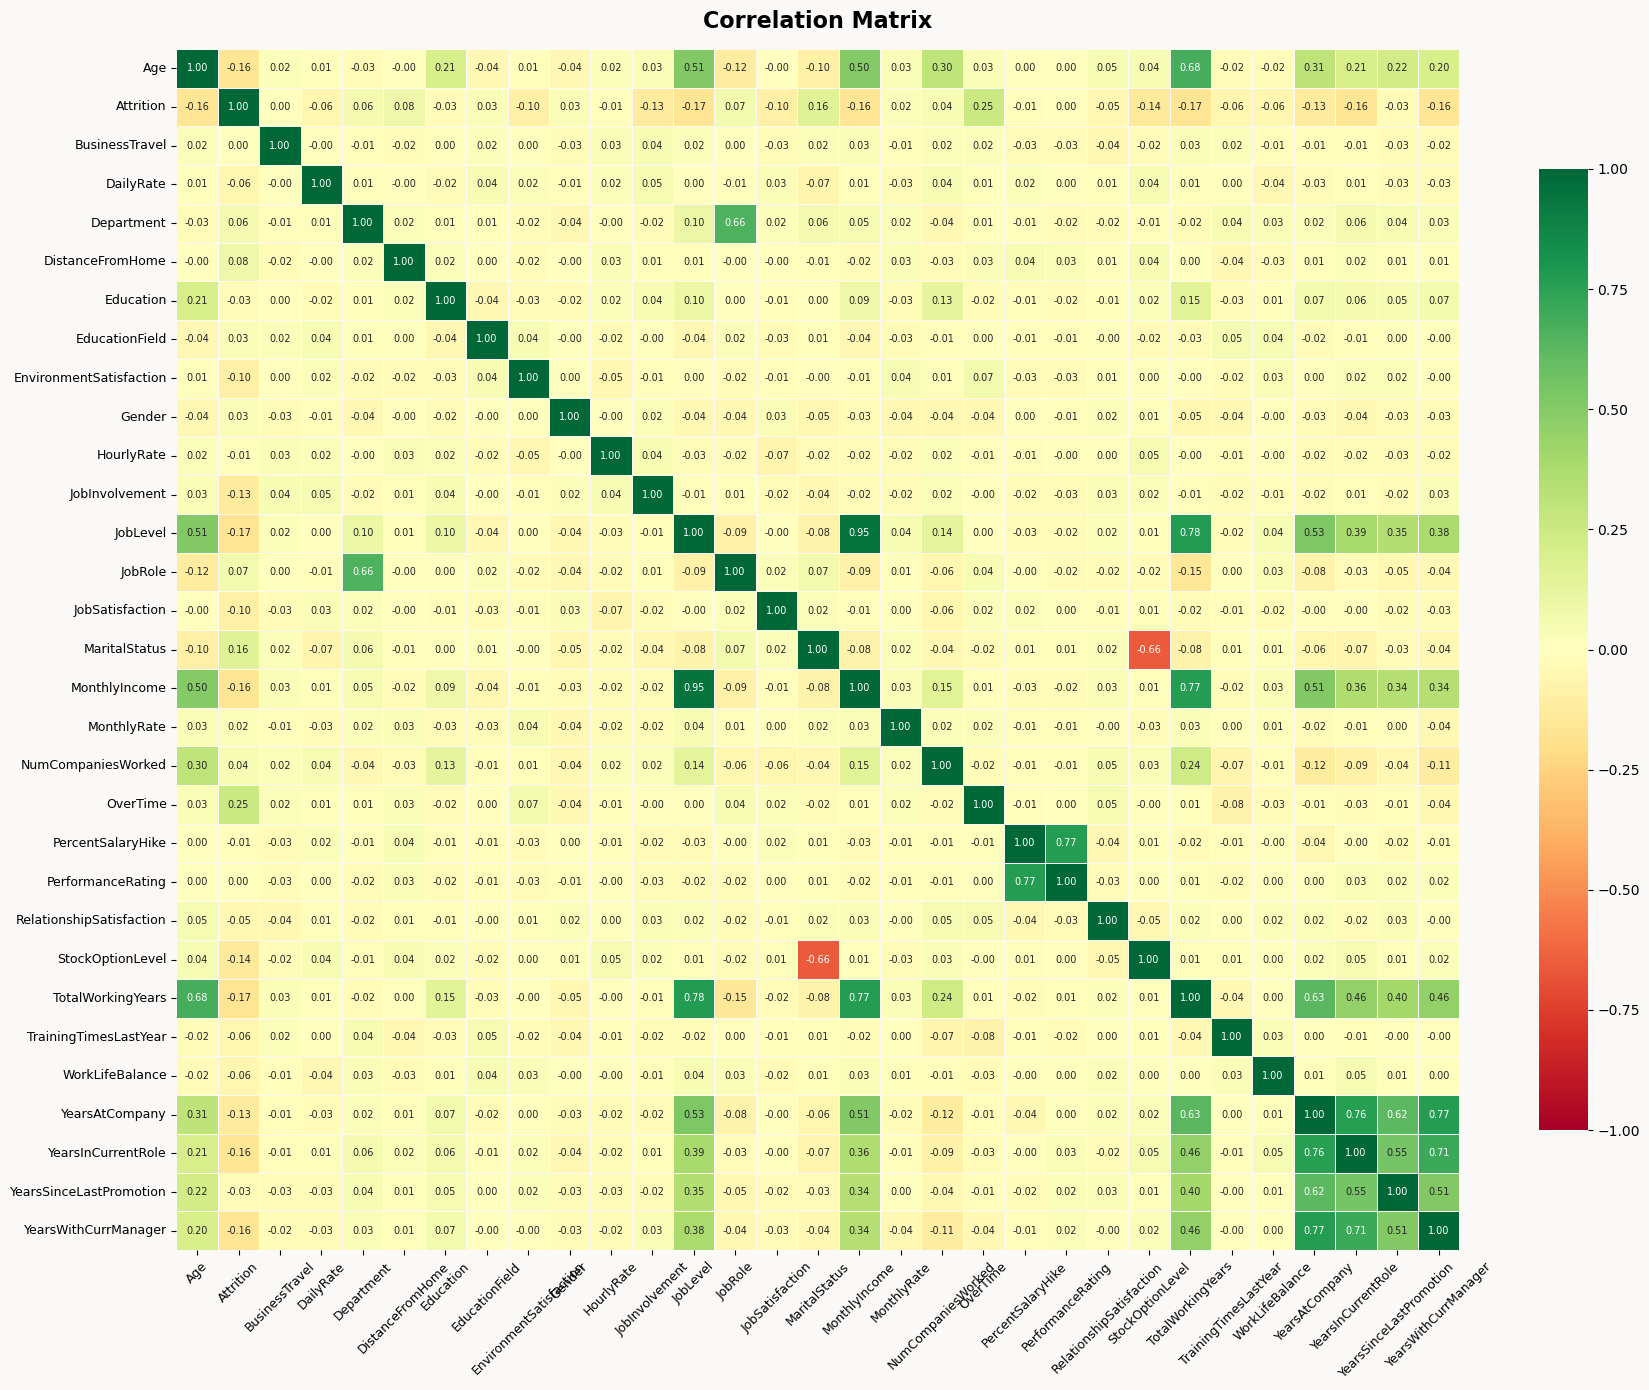

In [13]:
#Correlation Matrix to look at which columns have any correlation to Attrition
df_corr = df_0.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})

#Drop columns that are constant and non-informative
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18']
df_corr = df_corr.drop(columns=drop_cols)

#Change object columns to category 
obj_cols = df_corr.select_dtypes(include='object').columns
for col in obj_cols:
    df_corr[col] = df_corr[col].astype('category').cat.codes

corr_matrix = df_corr.corr().round(2)

fig, ax = plt.subplots(figsize=(18, 14))

fig.patch.set_facecolor('#fbf9f7')
ax.set_facecolor('#fbf9f7')

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='#fbf9f7',
    annot_kws={'size': 7},
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Correlation Matrix', fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.show()

In [14]:
#Prepare the data for modeling
df_model = df_0.copy()

#Find zero variance columns
zero_variance_cols = [col for col in df_model.select_dtypes(include='number').columns
                      if df_model[col].var() == 0]

#Include non-informative and ID columns
cols_to_drop = zero_variance_cols + ['EmployeeCount'] + ['EmployeeNumber'] + ['StandardHours'] + ['Over18']

df_model = df_model.drop(columns=cols_to_drop)

#Look for columns to convert to categorical which include object or columns with 1 to 5 ratings
cat_cols = [col for col in df_model.columns
            if df_model[col].dtype == 'object'
            or df_model[col].nunique() <= 5]

for col in cat_cols:
    df_model[col] = df_model[col].astype('category')

print("Columns that were dropped due to no variance or being noninformative:")
for col in zero_variance_cols:
    print(f"  - {col}")

print("\nColumns that were converted to categorical variables:")
for col in cat_cols:
    print(f"  - {col}")

Columns that were dropped due to no variance or being noninformative:
  - EmployeeCount
  - StandardHours

Columns that were converted to categorical variables:
  - Attrition
  - BusinessTravel
  - Department
  - Education
  - EducationField
  - EnvironmentSatisfaction
  - Gender
  - JobInvolvement
  - JobLevel
  - JobRole
  - JobSatisfaction
  - MaritalStatus
  - OverTime
  - PerformanceRating
  - RelationshipSatisfaction
  - StockOptionLevel
  - WorkLifeBalance


In [15]:
#Look for skewness
numeric_cols = df_model.select_dtypes(include='number').columns
skewness = df_model[numeric_cols].skew()

#Columns with skewness of .75 (.5 to 1 is considered skewed, so take the middle value)
skewed_cols = skewness[abs(skewness) > 0.75].index.tolist()

#Log transformation
for col in skewed_cols:
    df_model[col] = np.log1p(df_model[col])

print("Columns that were log transformed due to skewness above 0.75:")
for col in skewed_cols:
    print(f"  - {col} (skew: {skewness[col]:.4f})")

Columns that were log transformed due to skewness above 0.75:
  - DistanceFromHome (skew: 0.9581)
  - MonthlyIncome (skew: 1.3698)
  - NumCompaniesWorked (skew: 1.0265)
  - PercentSalaryHike (skew: 0.8211)
  - TotalWorkingYears (skew: 1.1172)
  - YearsAtCompany (skew: 1.7645)
  - YearsInCurrentRole (skew: 0.9174)
  - YearsSinceLastPromotion (skew: 1.9843)
  - YearsWithCurrManager (skew: 0.8335)


In [16]:
past_employees    = df_model[df_model['Attrition'] == 'Yes']['MonthlyIncome']
current_employees = df_model[df_model['Attrition'] == 'No']['MonthlyIncome']

#Used Levene's Test
levene_stat, levene_p = stats.levene(past_employees, current_employees)
equal_variance = levene_p > 0.05

print("=" * 60)
print("Levene's Test for Equality of Variances")
print("=" * 60)
print(f"  Levene Statistic : {levene_stat:.4f}")
print(f"  p-value          : {levene_p:.4f}")
print(f"  Equal Variances  : {equal_variance} (p {'>' if equal_variance else '<='} 0.05)")

#Independent T-Test
t_stat, p_value = stats.ttest_ind(past_employees, current_employees, equal_var=equal_variance)

print()
print("=" * 60)
print("Independent T-Test: Monthly Income by Attrition")
print("=" * 60)
print(f"  H0 : Average monthly income of past employees is the")
print(f"       same as employees still working")
print(f"  H1 : Average monthly income of past employees is")
print(f"       different from employees still working")
print()
print(f"  Past Employees    - Mean: {past_employees.mean():.4f}, N: {len(past_employees)}")
print(f"  Current Employees - Mean: {current_employees.mean():.4f}, N: {len(current_employees)}")
print()
print(f"  T-Statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.4f}")
print()
if p_value <= 0.05:
    print("  Result: Reject H0 — There is a statistically significant")
    print("          difference in average monthly income between")
    print("          past and current employees (p <= 0.05)")
else:
    print("  Result: Fail to Reject H0 — There is no statistically")
    print("          significant difference in average monthly income")
    print("          between past and current employees (p > 0.05)")
print("=" * 60)

Levene's Test for Equality of Variances
  Levene Statistic : 0.0944
  p-value          : 0.7586
  Equal Variances  : True (p > 0.05)

Independent T-Test: Monthly Income by Attrition
  H0 : Average monthly income of past employees is the
       same as employees still working
  H1 : Average monthly income of past employees is
       different from employees still working

  Past Employees    - Mean: 8.2525, N: 237
  Current Employees - Mean: 8.6105, N: 1233

  T-Statistic : -7.7477
  p-value     : 0.0000

  Result: Reject H0 — There is a statistically significant
          difference in average monthly income between
          past and current employees (p <= 0.05)


In [17]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score
from scipy.stats import randint

In [18]:
df_lr = df_model.copy()

#Encode category columns
cat_cols = df_lr.select_dtypes(include='category').columns.tolist()
df_lr = pd.get_dummies(df_lr, columns=cat_cols, drop_first=True)

#All boolean columns are integers
bool_cols = df_lr.select_dtypes(include='bool').columns
df_lr[bool_cols] = df_lr[bool_cols].astype(int)

#Separate features and target
attrition_col = [col for col in df_lr.columns if 'Attrition' in col][0]
X = df_lr.drop(columns=[col for col in df_lr.columns if 'Attrition' in col])
y = df_lr[attrition_col].astype(int)

print(f"Target column used : {attrition_col}")
print(f"Class distribution :\n{y.value_counts()}\n")


#TRAIN/VALIDATION/TEST SPLIT (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("=" * 60)
print("Dataset Split Summary")
print("=" * 60)
print(f"  Training   : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation : {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test       : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features   : {X_train.shape[1]}")
print("=" * 60)

#Scale the features
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

#Perform logistic regression
lr_model = LogisticRegression(
    max_iter     = 1000,
    class_weight = 'balanced',
    random_state = 42,
    solver       = 'lbfgs'
)

lr_model.fit(X_train_s, y_train)

#Evaluate the outcome
def evaluate_model(model, X_data, y_data, set_name):
    y_pred      = model.predict(X_data)
    y_pred_prob = model.predict_proba(X_data)[:, 1]
    accuracy    = accuracy_score(y_data, y_pred)
    auc         = roc_auc_score(y_data, y_pred_prob)

    print(f"\n{'=' * 60}")
    print(f"Model Evaluation — {set_name}")
    print(f"{'=' * 60}")
    print(f"  Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  AUC      : {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_data, y_pred, target_names=['Current Employee', 'Past Employee']))

evaluate_model(lr_model, X_val_s,  y_val,  "Validation Set")
evaluate_model(lr_model, X_test_s, y_test, "Test Set")

Target column used : Attrition_Yes
Class distribution :
Attrition_Yes
0    1233
1     237
Name: count, dtype: int64

Dataset Split Summary
  Training   : 882 rows (60.0%)
  Validation : 294 rows (20.0%)
  Test       : 294 rows (20.0%)
  Features   : 62

Model Evaluation — Validation Set
  Accuracy : 0.7891 (78.91%)
  AUC      : 0.8413

Classification Report:
                  precision    recall  f1-score   support

Current Employee       0.93      0.81      0.87       246
   Past Employee       0.41      0.69      0.52        48

        accuracy                           0.79       294
       macro avg       0.67      0.75      0.69       294
    weighted avg       0.85      0.79      0.81       294


Model Evaluation — Test Set
  Accuracy : 0.7925 (79.25%)
  AUC      : 0.8374

Classification Report:
                  precision    recall  f1-score   support

Current Employee       0.95      0.80      0.87       247
   Past Employee       0.42      0.77      0.54        47

        ac

Target column used: Attrition_Yes
Class distribution:
Attrition_Yes
0    1233
1     237
Name: count, dtype: int64

Dataset Split Summary
  Training   : 882 rows (60.0%)
  Validation : 294 rows (20.0%)
  Test       : 294 rows (20.0%)
  Features   : 62
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters Found
  class_weight             : None
  max_depth                : None
  max_features             : log2
  min_samples_leaf         : 8
  min_samples_split        : 17
  n_estimators             : 336

Top 15 Most Important Features
  MonthlyIncome                           : 0.1041
  Age                                     : 0.0766
  OverTime_Yes                            : 0.0740
  TotalWorkingYears                       : 0.0676
  YearsAtCompany                          : 0.0523
  YearsWithCurrManager                    : 0.0470
  DailyRate                               : 0.0423
  HourlyRate                              : 0.0408
  MonthlyRate        

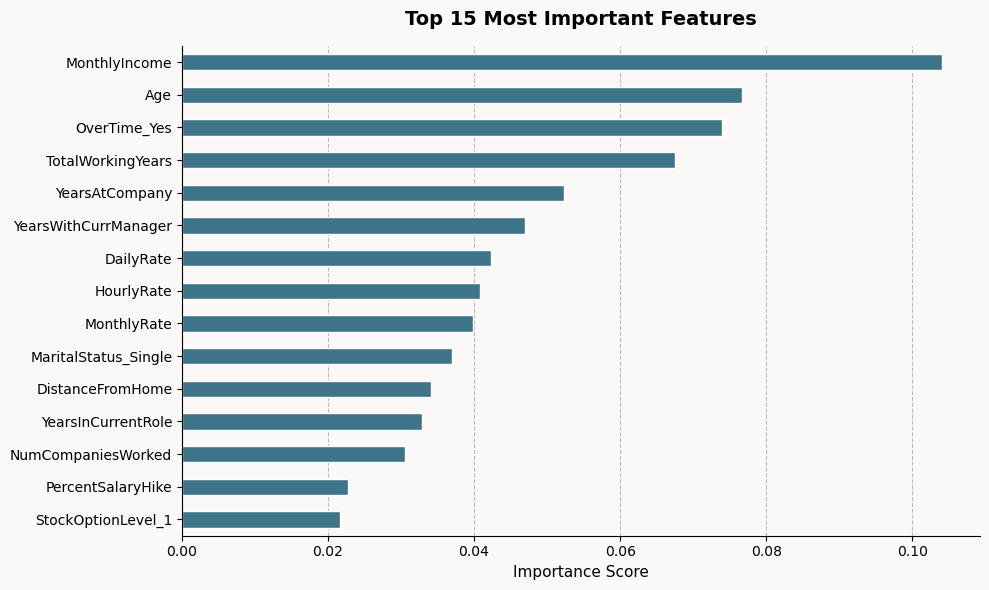


Model Evaluation — Validation Set
  Accuracy : 0.8333 (83.33%)
  AUC      : 0.7952

Classification Report:
                  precision    recall  f1-score   support

Current Employee       0.84      0.99      0.91       246
   Past Employee       0.33      0.02      0.04        48

        accuracy                           0.83       294
       macro avg       0.59      0.51      0.47       294
    weighted avg       0.76      0.83      0.77       294


Model Evaluation — Test Set
  Accuracy : 0.8469 (84.69%)
  AUC      : 0.7719

Classification Report:
                  precision    recall  f1-score   support

Current Employee       0.85      1.00      0.92       247
   Past Employee       1.00      0.04      0.08        47

        accuracy                           0.85       294
       macro avg       0.92      0.52      0.50       294
    weighted avg       0.87      0.85      0.78       294



In [19]:
df_rf = df_model.copy()

#Encode category columns
cat_cols = df_rf.select_dtypes(include='category').columns.tolist()
df_rf = pd.get_dummies(df_rf, columns=cat_cols, drop_first=True)

#All boolean columns are integers
bool_cols = df_rf.select_dtypes(include='bool').columns
df_rf[bool_cols] = df_rf[bool_cols].astype(int)

#Separate features and target
attrition_col = [col for col in df_rf.columns if 'Attrition' in col][0]
X = df_rf.drop(columns=[col for col in df_rf.columns if 'Attrition' in col])
y = df_rf[attrition_col].astype(int)

print(f"Target column used: {attrition_col}")
print(f"Class distribution:\n{y.value_counts()}\n")

#TRAIN/VALIDATION/TEST SPLIT (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("=" * 60)
print("Dataset Split Summary")
print("=" * 60)
print(f"  Training   : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation : {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test       : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features   : {X_train.shape[1]}")
print("=" * 60)

#Scale the features
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

#Perform parameter tuning and random forest model 
param_dist = {
    'n_estimators'      : randint(100, 500),
    'max_depth'         : [None, 5, 10, 15, 20, 25],
    'min_samples_split' : randint(2, 20),
    'min_samples_leaf'  : randint(1, 10),
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : ['balanced', None]
}

rf_base = RandomForestClassifier(random_state=42)

rf_search = RandomizedSearchCV(
    estimator          = rf_base,
    param_distributions= param_dist,
    n_iter             = 50,
    cv                 = 5,
    scoring            = 'roc_auc',
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 1
)

rf_search.fit(X_train_s, y_train)
best_rf = rf_search.best_estimator_

print("\n" + "=" * 60)
print("Best Hyperparameters Found")
print("=" * 60)
for param, value in rf_search.best_params_.items():
    print(f"  {param:<25}: {value}")

#Look at feature importance
feature_importances = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

top_features = feature_importances.head(15)

print("\n" + "=" * 60)
print("Top 15 Most Important Features")
print("=" * 60)
for feat, score in top_features.items():
    print(f"  {feat:<40}: {score:.4f}")

# Plot feature importances
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#fbf9f7')
ax.set_facecolor('#fbf9f7')

top_features.sort_values().plot(
    kind='barh', ax=ax, color='#3d7489', edgecolor='white'
)

ax.set_title('Top 15 Most Important Features', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('')
ax.yaxis.grid(False)
ax.xaxis.grid(True, linestyle='--', color='gray', alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#Outcome evaluation
def evaluate_model(model, X_data, y_data, set_name):
    y_pred      = model.predict(X_data)
    y_pred_prob = model.predict_proba(X_data)[:, 1]
    accuracy    = accuracy_score(y_data, y_pred)
    auc         = roc_auc_score(y_data, y_pred_prob)

    print(f"\n{'=' * 60}")
    print(f"Model Evaluation — {set_name}")
    print(f"{'=' * 60}")
    print(f"  Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  AUC      : {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_data, y_pred, target_names=['Current Employee', 'Past Employee']))

evaluate_model(best_rf, X_val_s,  y_val,  "Validation Set")
evaluate_model(best_rf, X_test_s, y_test, "Test Set")

Model Comparison — Metric Summary Table
                  Accuracy     AUC  Precision  Recall  F1-Score  Avg Precision
RF  — Validation    0.8333  0.7952     0.3333  0.0208    0.0392         0.4285
RF  — Test          0.8469  0.7719     1.0000  0.0426    0.0816         0.5128
LR  — Validation    0.7891  0.8413     0.4125  0.6875    0.5156         0.5824
LR  — Test          0.7925  0.8374     0.4186  0.7660    0.5414         0.6587


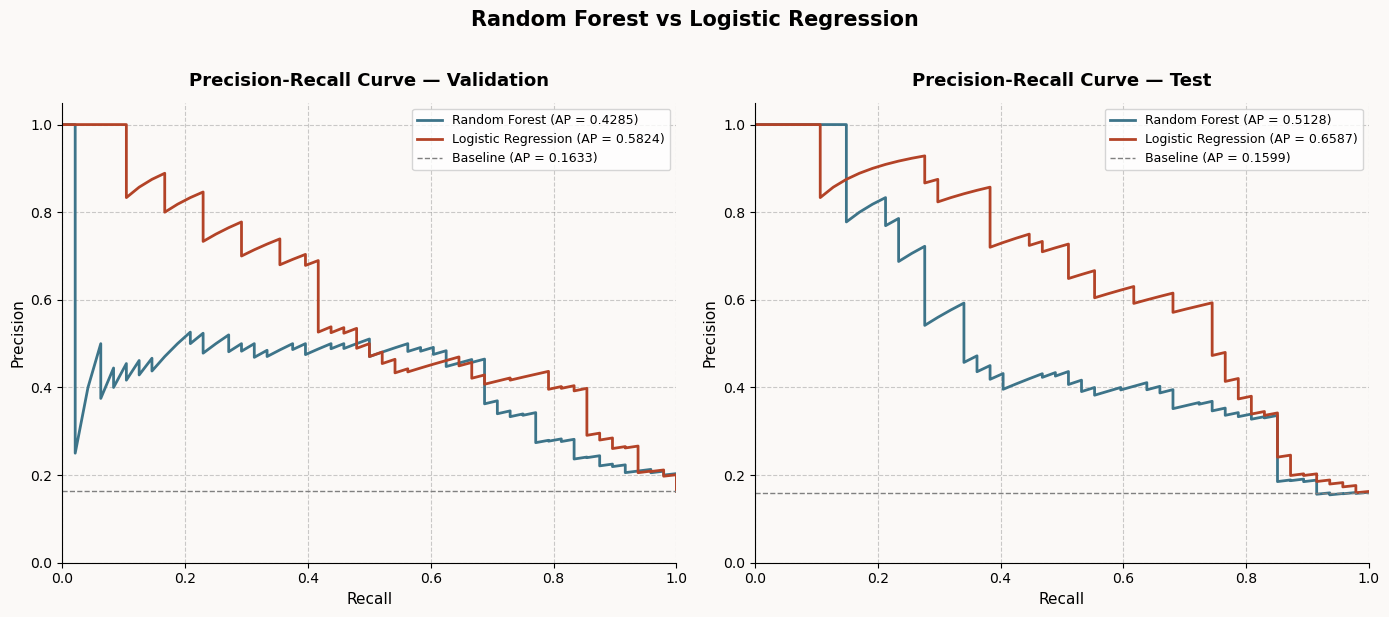

In [20]:
#Compare the outcome metrics
def get_metrics(model, X_data, y_data):
    y_pred      = model.predict(X_data)
    y_pred_prob = model.predict_proba(X_data)[:, 1]
    return {
        'Accuracy'  : round(accuracy_score(y_data, y_pred), 4),
        'AUC'       : round(roc_auc_score(y_data, y_pred_prob), 4),
        'Precision' : round(precision_score(y_data, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_data, y_pred), 4),
        'F1-Score'  : round(f1_score(y_data, y_pred), 4),
        'Avg Precision' : round(average_precision_score(y_data, y_pred_prob), 4)
    }

metrics = {
    'RF  — Validation' : get_metrics(best_rf,   X_val_s,  y_val),
    'RF  — Test'       : get_metrics(best_rf,   X_test_s, y_test),
    'LR  — Validation' : get_metrics(lr_model,  X_val_s,  y_val),
    'LR  — Test'       : get_metrics(lr_model,  X_test_s, y_test)
}

metrics_df = pd.DataFrame(metrics).T

print("=" * 70)
print("Model Comparison — Metric Summary Table")
print("=" * 70)
print(metrics_df.to_string())
print("=" * 70)

#Compare the precision recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#fbf9f7')

sets = [
    ('Validation', X_val_s,  y_val),
    ('Test',       X_test_s, y_test)
]

for ax, (set_name, X_data, y_data) in zip(axes, sets):
    ax.set_facecolor('#fbf9f7')

    #Random Forest
    rf_probs          = best_rf.predict_proba(X_data)[:, 1]
    rf_precision, rf_recall, _ = precision_recall_curve(y_data, rf_probs)
    rf_avg_precision  = average_precision_score(y_data, rf_probs)

    #Logistic Regression
    lr_probs          = lr_model.predict_proba(X_data)[:, 1]
    lr_precision, lr_recall, _ = precision_recall_curve(y_data, lr_probs)
    lr_avg_precision  = average_precision_score(y_data, lr_probs)

    #Baseline
    baseline = y_data.sum() / len(y_data)

    ax.plot(rf_recall, rf_precision, color='#3d7489', linewidth=2,
            label=f'Random Forest (AP = {rf_avg_precision:.4f})')
    ax.plot(lr_recall, lr_precision, color='#b34327', linewidth=2,
            label=f'Logistic Regression (AP = {lr_avg_precision:.4f})')
    ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1,
               label=f'Baseline (AP = {baseline:.4f})')

    ax.set_title(f'Precision-Recall Curve — {set_name}', fontsize=13,
                 fontweight='bold', pad=12)
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(fontsize=9, loc='upper right', title=None)
    ax.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Random Forest vs Logistic Regression', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()